<a href="https://colab.research.google.com/github/hhustlerr/Finance_Project_Pune/blob/main/stratazeal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [ ]:
df = pd.read_csv("/content/Securebank_fraud_dataset - Sheet1.csv")
df = df.iloc[:, :-4]

In [ ]:
df.shape

(10000, 19)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       10000 non-null  int64  
 1   Location                  10000 non-null  object 
 2   Account_Type              10000 non-null  object 
 3   Transaction_Amount        10000 non-null  int64  
 4   Transaction_Hour          10000 non-null  int64  
 5   Channel                   10000 non-null  object 
 6   Avg_Monthly_Transactions  10000 non-null  int64  
 7   Avg_Transaction_Amount    10000 non-null  int64  
 8   Past_Fraud_Flag           10000 non-null  int64  
 9   Fraud                     10000 non-null  int64  
 10  Txn_Frequency_Band        10000 non-null  object 
 11  Credit_Score              10000 non-null  int64  
 12  Customer_Tenure           10000 non-null  int64  
 13  Avg_Daily_Balance         10000 non-null  int64  
 14  Linked_

In [ ]:
# CLEANING THE DATASET

df.isnull().sum()


# DIVING THE COLUMNS INTO NUMERICAL AND CATEGORICAL ONES
num_cols = df.select_dtypes(include = 'number').columns
cat_cols = df.select_dtypes(include = "object").columns


# CHECKING FOR DUPLICATES
df.duplicated().sum()


# is_neg_txn tells whether there is any fruad or chargeback
# tranasctrion amount will tell the magnitude of the amount transfers
df["is_negative_txn"] = (df["Transaction_Amount"]<0).astype(int)
df["Transaction_Amount"] = df["Transaction_Amount"].abs()
(df["Transaction_Amount"]<0).sum()


df['Fraud'].value_counts(normalize = True)

,proportion
Fraud,
0,0.8623
1,0.1377


## Cleaning insights
1. no null value is present
2. divding the columns into numerical and categorical columns for further analysis
3. separating the negative transaction amt from tranaction amount column
4. shows imbalance data such that fraud is about 13.77% and 86.23% is legitimate

# EDA BEGINS



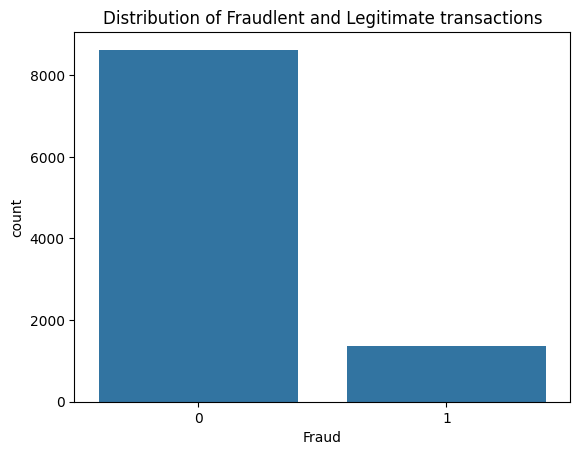

In [ ]:
sns.countplot(x = 'Fraud', data = df)
plt.title('Distribution of Fraudlent and Legitimate transactions')
plt.show()

This visualization confirms the class imbalance, highlighting the needs for the use like oversampling, undersampling or anomaly detection in modelling steps

## WORKING ON NUMERICAL FEATURES

In [ ]:
num_cols

Index(['Age', 'Transaction_Amount', 'Transaction_Hour',
       'Avg_Monthly_Transactions', 'Avg_Transaction_Amount', 'Past_Fraud_Flag',
       'Fraud', 'Credit_Score', 'Customer_Tenure', 'Avg_Daily_Balance',
       'Linked_Accounts', 'Region_Risk_Score', 'Digital_Literacy',
       'Suspicious_Keyword_Flag'],
      dtype='object')

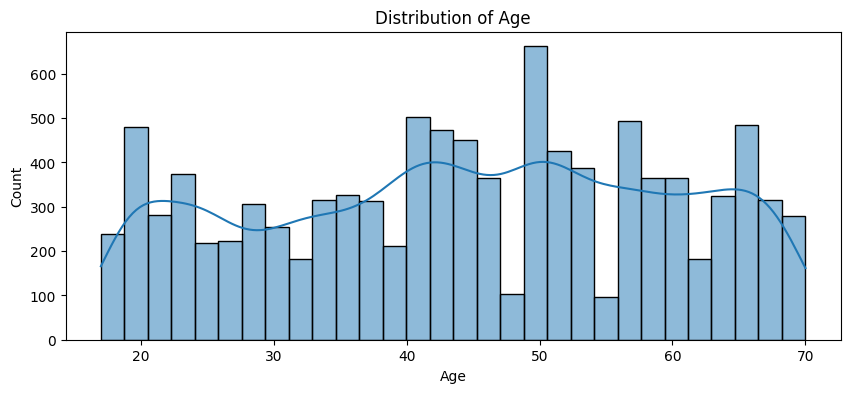

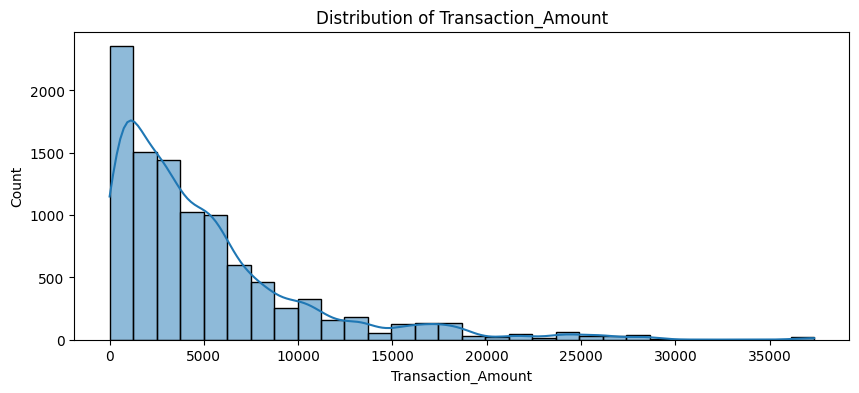

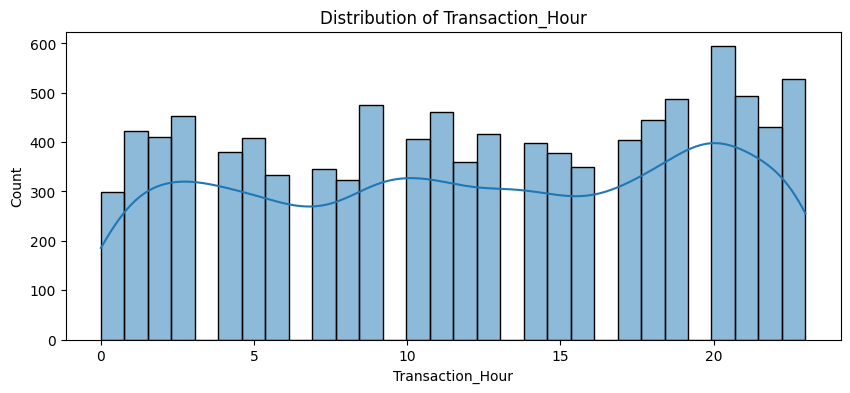

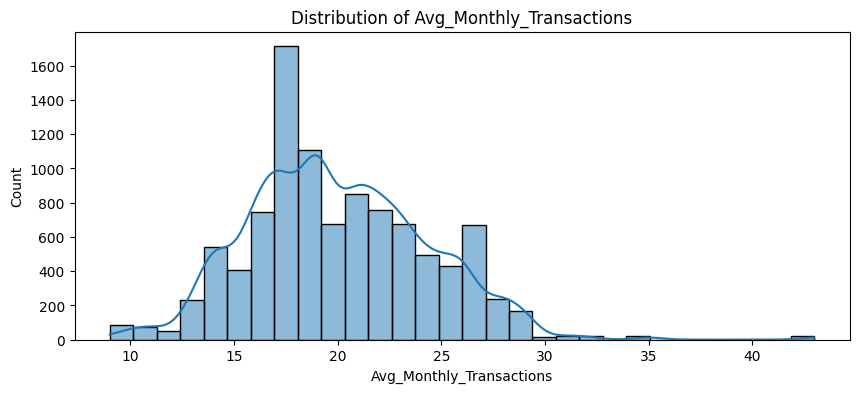

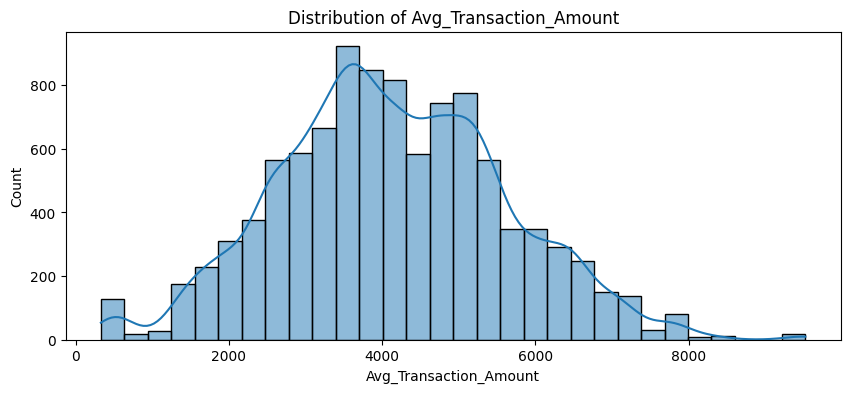

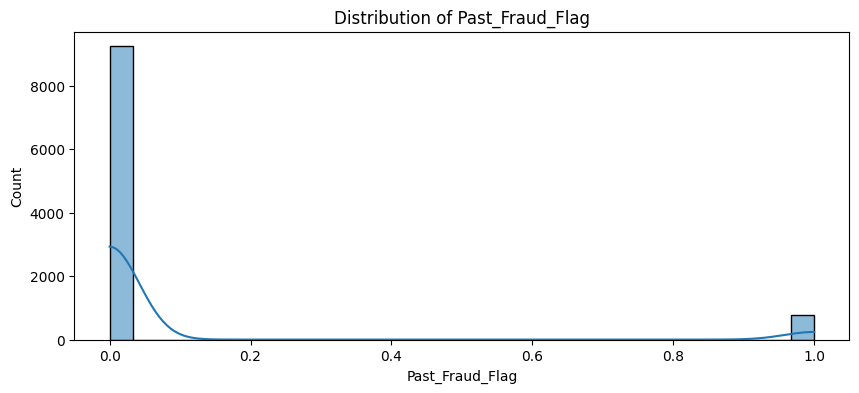

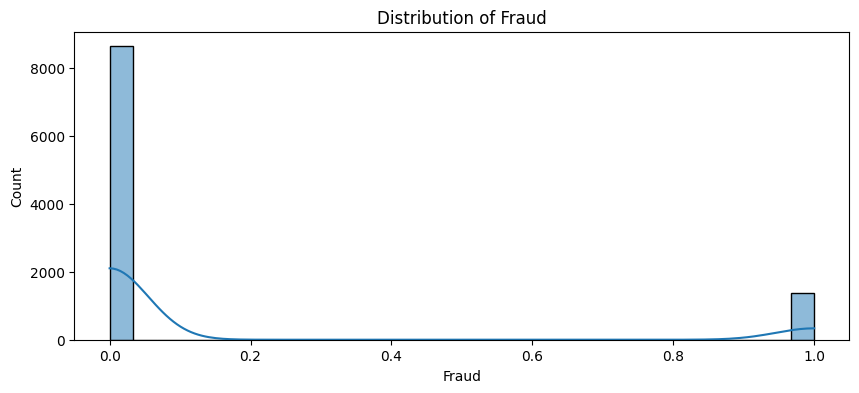

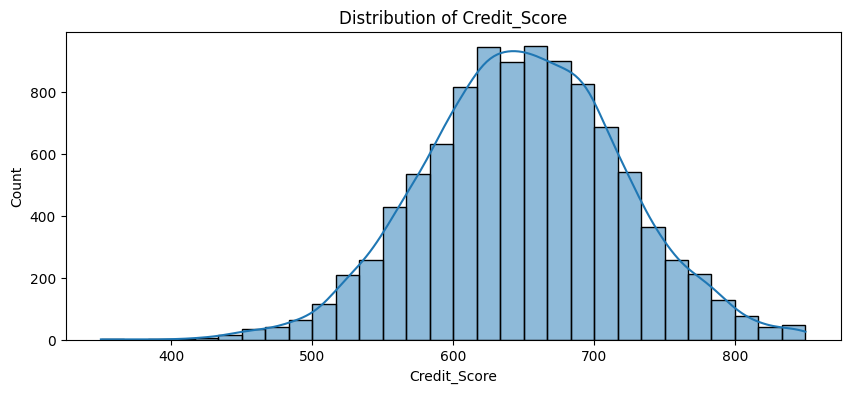

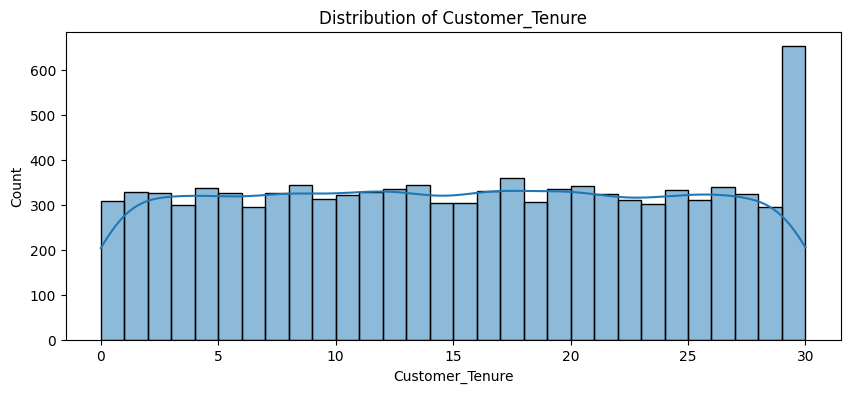

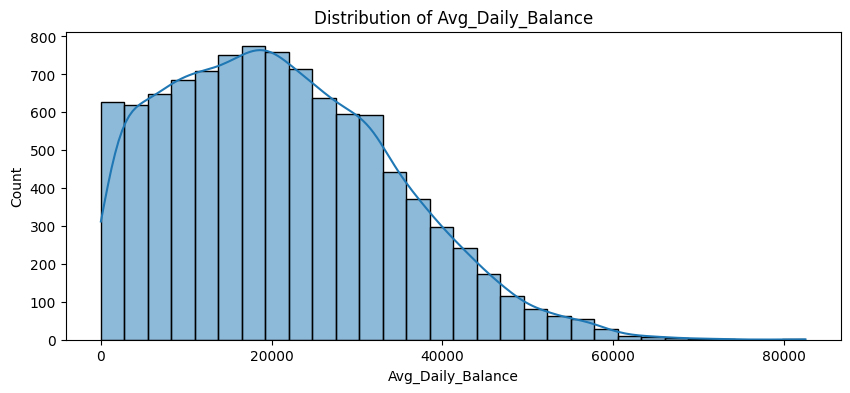

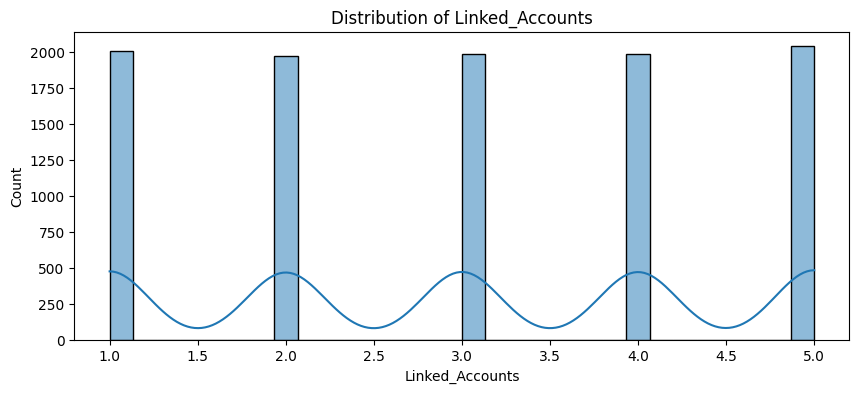

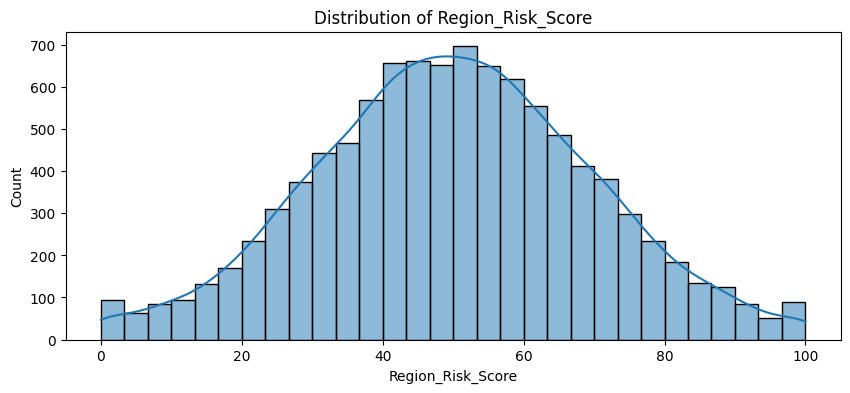

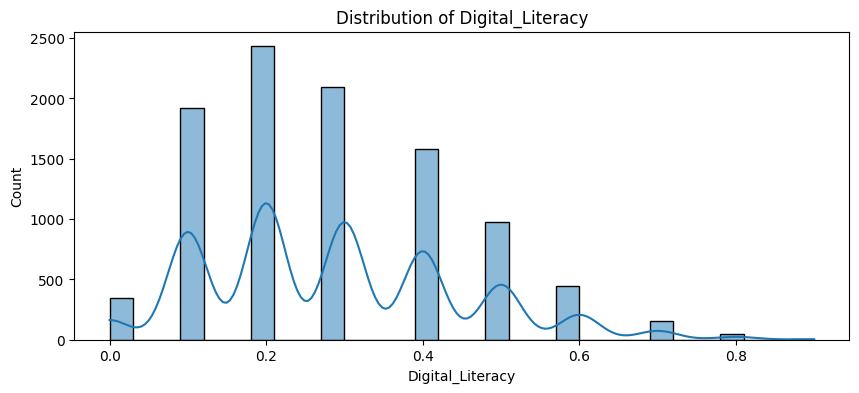

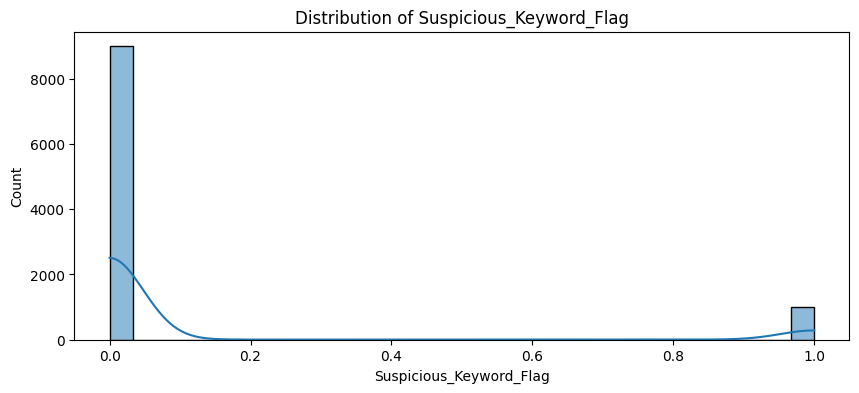

In [ ]:
# # deteted on outliers
# for col in num_cols:
#   q1 = df[col].quantile(0.25)
#   q3 = df[col].quantile(0.75)
#   iqr = q3-q1
#   lower_limit = q1 - 1.5*iqr
#   upper_limit = q3 + 1.5*iqr
#   df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

for col in num_cols:
  plt.figure(figsize = (10,4))
  sns.histplot(df[col], kde = True, bins = 30)
  plt.title(f"Distribution of {col}")
  plt.show(col)

  # plt.figure(figsize = (10,5))
  # sns.boxplot(x = 'Fraud', y= col, data = df)
  # plt.title(f"{col} v/s Farud ")
  # plt.show()

# Work on Categorical Columns

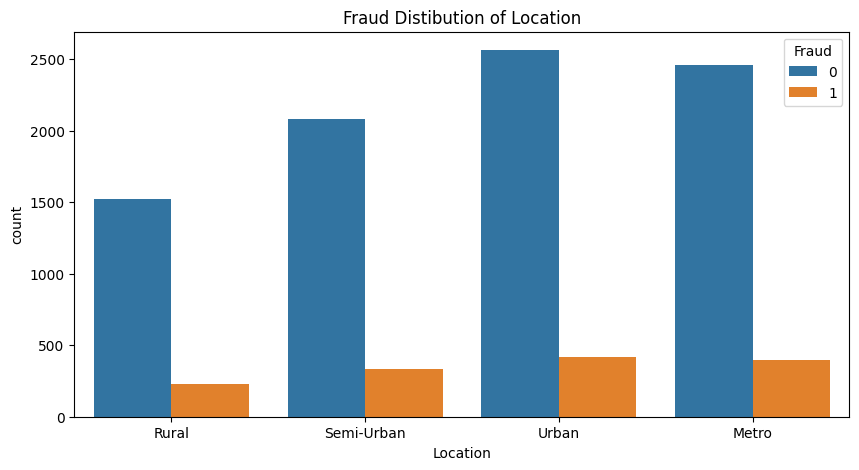

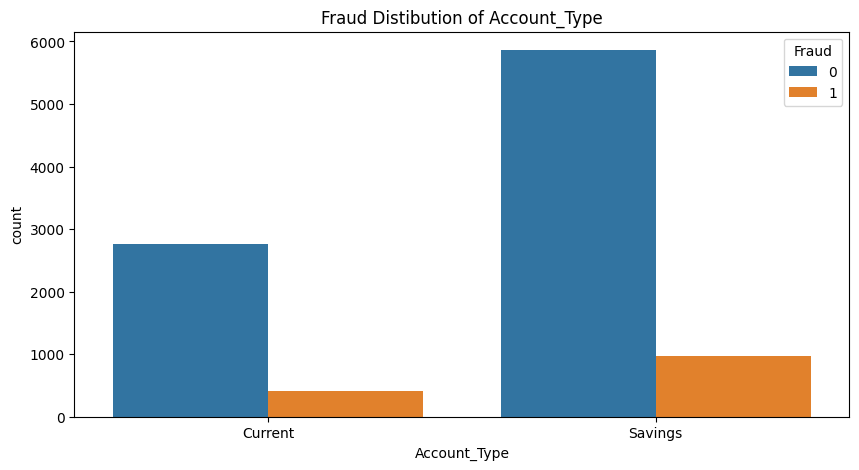

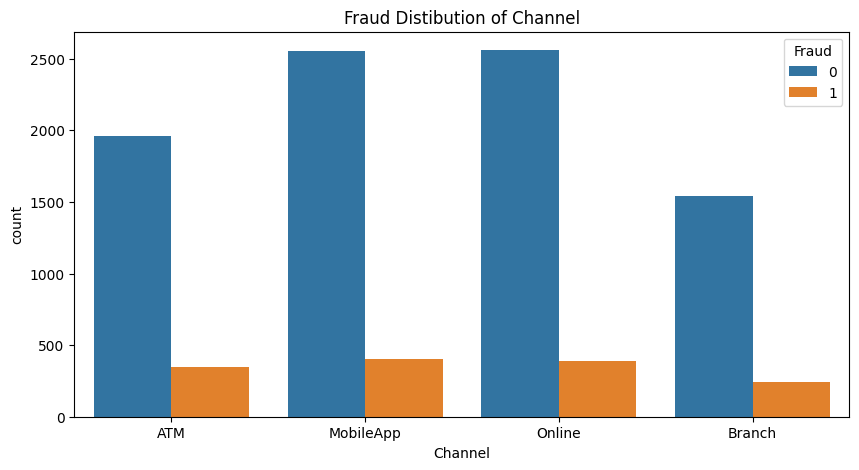

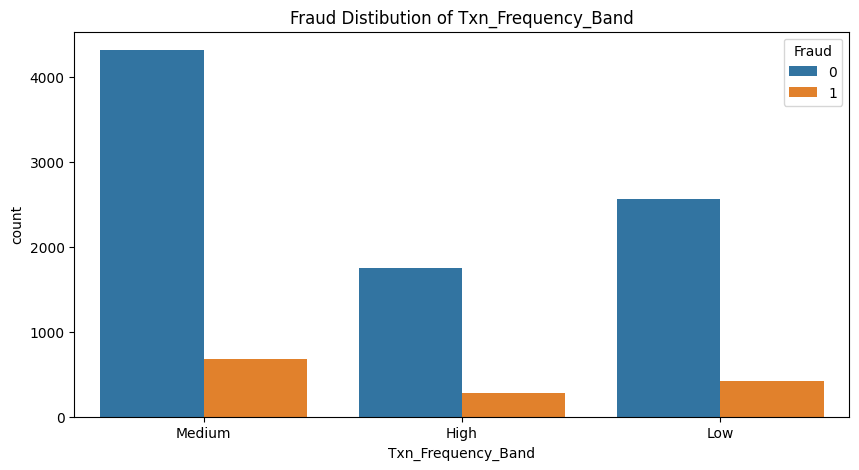

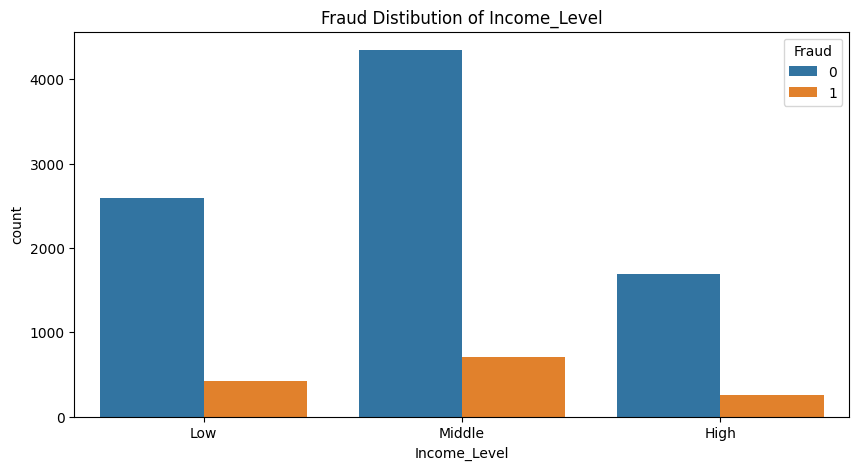

In [ ]:
for col in cat_cols:
  plt.figure(figsize = (10,5))
  sns.countplot(x = col, hue = 'Fraud', data = df)
  plt.title(f"Fraud Distibution of {col}")
  plt.show()

for creating ml models we have to convert these categorical columns into numerical ones for this i will be using one-hot encoding

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# df_encoded = pd.get_dummies(df, columns = cat_cols, drop_first = True)
encoder = OneHotEncoder(drop = 'first', sparse_output = False)
encoded = encoder.fit_transform(df[cat_cols])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(cat_cols))

# Concatenate with original dataframe (excluding original categorical columns)
df_final = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)
df_final

,Age,Transaction_Amount,Transaction_Hour,Avg_Monthly_Transactions,Avg_Transaction_Amount,Past_Fraud_Flag,Fraud,Credit_Score,Customer_Tenure,Avg_Daily_Balance,...,Location_Semi-Urban,Location_Urban,Account_Type_Savings,Channel_Branch,Channel_MobileApp,Channel_Online,Txn_Frequency_Band_Low,Txn_Frequency_Band_Medium,Income_Level_Low,Income_Level_Middle
0,37,785,12,14,5586,0,0,758,23,1874,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,63,734,2,21,1851,0,0,649,30,24538,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
2,20,8238,20,17,2055,0,0,652,14,35660,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,40,2989,22,22,4132,0,0,741,18,19457,...,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,56,2762,6,17,4149,0,0,553,10,13047,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,24,5769,15,19,2783,0,0,722,3,25177,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
9996,25,1345,5,19,5064,1,0,653,23,14305,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
9997,57,196,10,19,3305,0,0,773,26,49380,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
9998,54,2936,4,20,3064,0,0,683,11,39517,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


# Temporal analysis

In [ ]:
df['Location'].unique()

array(['Rural', 'Semi-Urban', 'Urban', 'Metro'], dtype=object)

In [ ]:
df.columns

Index(['Age', 'Location', 'Account_Type', 'Transaction_Amount',
       'Transaction_Hour', 'Channel', 'Avg_Monthly_Transactions',
       'Avg_Transaction_Amount', 'Past_Fraud_Flag', 'Fraud',
       'Txn_Frequency_Band', 'Credit_Score', 'Customer_Tenure',
       'Avg_Daily_Balance', 'Linked_Accounts', 'Region_Risk_Score',
       'Income_Level', 'Digital_Literacy', 'Suspicious_Keyword_Flag',
       'is_negative_txn'],
      dtype='object')

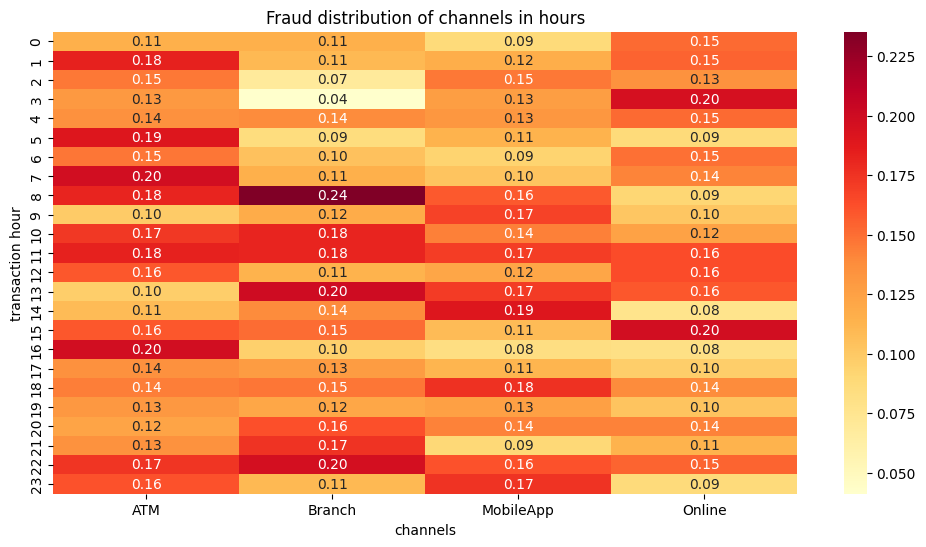

In [ ]:
df['Transaction_Hour']
# creating the pivot table
fraud_heatmap = df.pivot_table(values = "Fraud", index = "Transaction_Hour", columns = ["Channel"], aggfunc = "mean")
# plotting the heatmap
plt.figure(figsize = (12,6))
sns.heatmap(fraud_heatmap, annot = True, fmt = ".2f", cmap = "YlOrRd")
plt.title("Fraud distribution of channels in hours")
plt.xlabel("channels")
plt.ylabel("transaction hour")
plt.show()

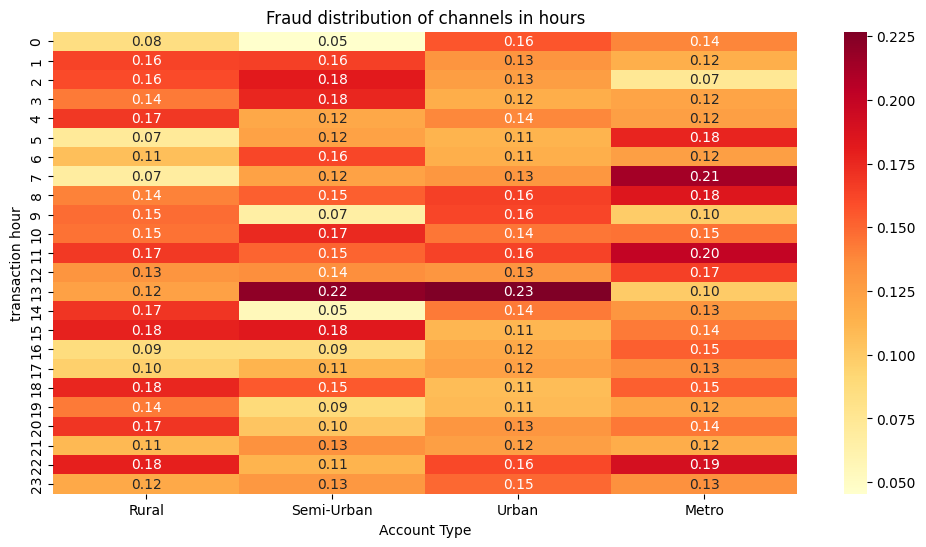

In [ ]:
# creating the pivot table
fraud_heatmap = df.pivot_table(values = "Fraud", index = "Transaction_Hour", columns = ["Location"], aggfunc = "mean")
# plotting the heatmap
plt.figure(figsize = (12,6))
sns.heatmap(fraud_heatmap, annot = True, fmt = ".2f", cmap = "YlOrRd", xticklabels = ["Rural", "Semi-Urban", "Urban", "Metro"])
plt.title("Fraud distribution of channels in hours")
plt.xlabel("Account Type")
plt.ylabel("transaction hour")
plt.show()

## QUESTION 1
Which factors have the strongest link with whether a transaction turns out to be fraud or not?

In [ ]:
# Getting numeric columns (excluding target)
numeric_cols = [col for col in df.select_dtypes(include='number').columns if col != 'Fraud']

# numeric correlation with Fraud
numeric_corr = df[numeric_cols + ['Fraud']].corr()['Fraud'].drop('Fraud')

# sorting by absolute correlation
numeric_corr = numeric_corr.reindex(numeric_corr.abs().sort_values(ascending=False).index)

print(numeric_corr)


Avg_Daily_Balance           0.018034
is_negative_txn             0.014796
Customer_Tenure             0.013222
Suspicious_Keyword_Flag    -0.012594
Linked_Accounts            -0.011013
Credit_Score               -0.008078
Avg_Transaction_Amount      0.007837
Transaction_Amount          0.007740
Region_Risk_Score           0.007015
Past_Fraud_Flag             0.006011
Avg_Monthly_Transactions   -0.003105
Transaction_Hour            0.002891
Digital_Literacy           -0.001481
Age                        -0.000248
Name: Fraud, dtype: float64


Location : Location
Rural         0.131925
Semi-Urban    0.137645
Metro         0.138451
Urban         0.140416
Name: Fraud, dtype: float64
Account_Type : Account_Type
Current    0.128747
Savings    0.141853
Name: Fraud, dtype: float64
Channel : Channel
Online       0.131275
Branch       0.135650
MobileApp    0.135857
ATM          0.149848
Name: Fraud, dtype: float64
Txn_Frequency_Band : Txn_Frequency_Band
High      0.135282
Medium    0.136545
Low       0.141275
Name: Fraud, dtype: float64
Income_Level : Income_Level
High      0.130412
Low       0.139009
Middle    0.139719
Name: Fraud, dtype: float64


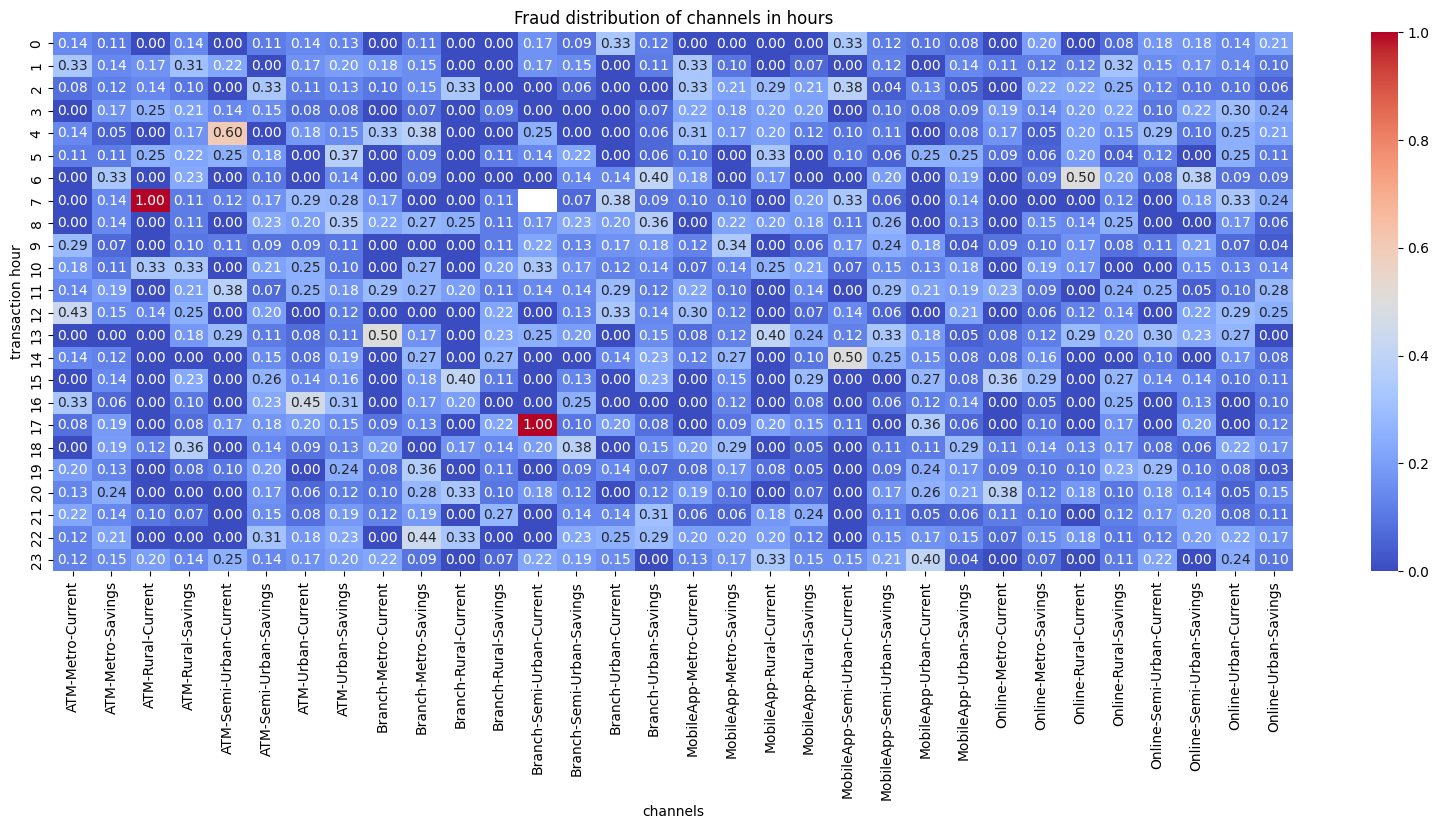

In [ ]:
# for categorical columns
for col in cat_cols:
  fraud_rate = df.groupby(col)["Fraud"].mean().sort_values(ascending = True)
  print(f"{col} : {fraud_rate}")

df['Transaction_Hour']
# creating the pivot table
fraud_heatmap = df.pivot_table(values = "Fraud", index = "Transaction_Hour", columns = ["Channel", "Location", "Account_Type"], aggfunc = "mean")
# plotting the heatmap
plt.figure(figsize = (20,7))
sns.heatmap(fraud_heatmap, annot = True, fmt = ".2f", cmap = "coolwarm")
# Flatten MultiIndex columns into single string labels
fraud_heatmap.columns = ['_'.join(col).strip() for col in fraud_heatmap.columns.values]

plt.title("Fraud distribution of channels in hours")
plt.xlabel("channels")
plt.ylabel("transaction hour")
plt.show()

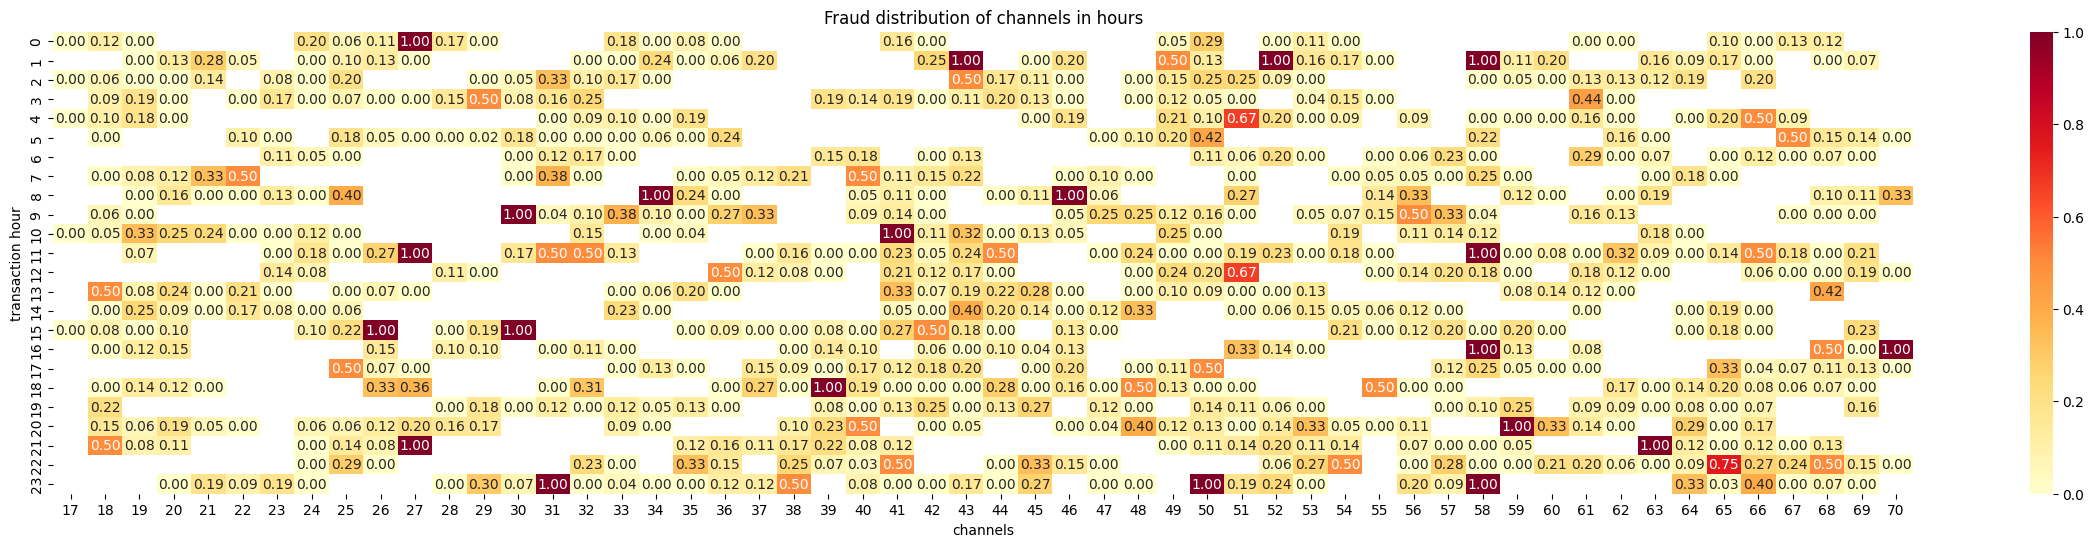

In [ ]:
df['Transaction_Hour']
# creating the pivot table
fraud_heatmap = df.pivot_table(values = "Fraud", index = "Transaction_Hour", columns = ["Age"], aggfunc = "mean")
# plotting the heatmap
plt.figure(figsize = (30,6))
sns.heatmap(fraud_heatmap, annot = True, fmt = ".2f", cmap = "YlOrRd")
plt.title("Fraud distribution of channels in hours")
plt.xlabel("channels")
plt.ylabel("transaction hour")
plt.show()

# Answer 1
Numerical features alone are very weak indicators of fraud where Categorical features like Channel, Account_Type, Txn_Frequency_Band, and Location show stronger links to fraud.
Factors with a strong link to fraud includes(ranked roughly according to their strength):
1. Channel – ATM transactions are the riskiest.

2. Account_Type – Savings accounts show slightly higher fraud.

3. Transaction Frequency Band – Low-frequency transactions are slightly riskier.

5. Location – Urban areas have slightly higher fraud.

6. Income_Level – Low/Middle slightly higher fraud than High.


## Overall:
1. Channel - ATM, Location - Rural, Account-Type - Savings at around 7am found to be the strong indicators of fraud.

2.  Channel - Branch, Location - Semi-Urban, Account-Type - Current at around 5pm found to be the strong indicators of fraud.

3. Semi urban and urban locations 1pm having great chances of fraud

4. For Age > 25 and Age < 60 are having stronger links to fraud


# QUESTION 2
Find temporal and channel-wise patterns of fraud being committed. Present it graphically to clearly identify peak fraud
windows for potential focused real-time monitoring.

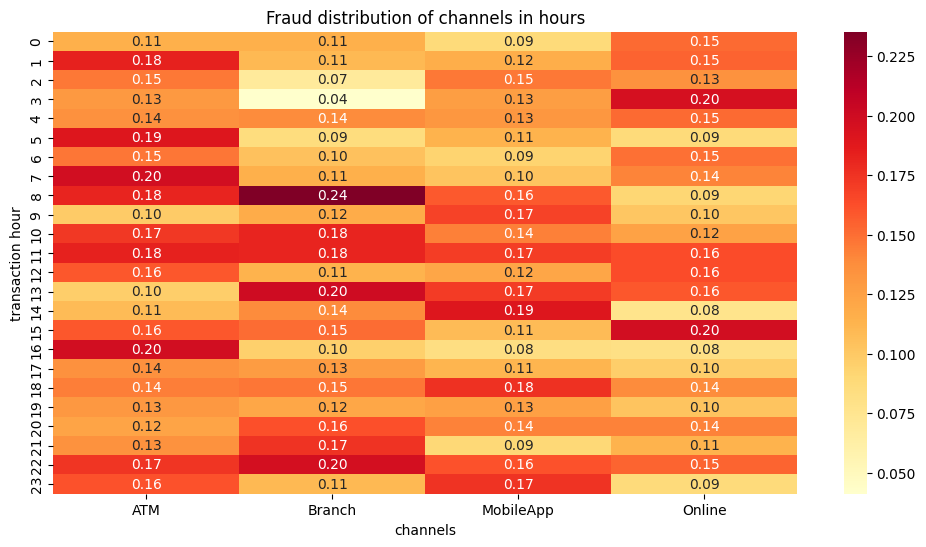

In [ ]:
df['Transaction_Hour']
# creating the pivot table
fraud_heatmap = df.pivot_table(values = "Fraud", index = "Transaction_Hour", columns = ["Channel"], aggfunc = "mean")
# plotting the heatmap
plt.figure(figsize = (12,6))
sns.heatmap(fraud_heatmap, annot = True, fmt = ".2f", cmap = "YlOrRd")
plt.title("Fraud distribution of channels in hours")
plt.xlabel("channels")
plt.ylabel("transaction hour")
plt.show()

# ANSWER 2
The high number of fraud distributions have been detected in channel ATM at around 5am-8am and then 4pm and 10pm to 11pm.

BUT...

The higher chances of fraud found in channel Branch at around 8am

# QUESTION 3
Find out if the Region Risk Score is related to fraud, and show how strong this connection is. Then, do the same for the
cardholder’s Credit Score and Average transaction amount.


Region Risk Score correlation: 0.007015312762407173 p-value: 0.4830208487458465
Credit Score correlation: -0.00807810114333031 p-value: 0.4192504575988176
Avg Transaction Amount correlation: 0.007837349258794589 p-value: 0.4332461029170159


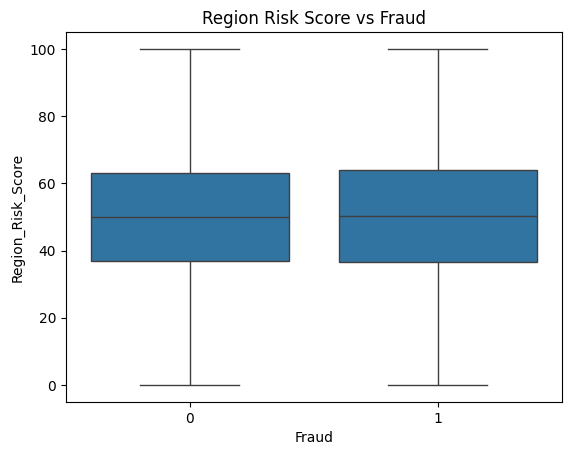

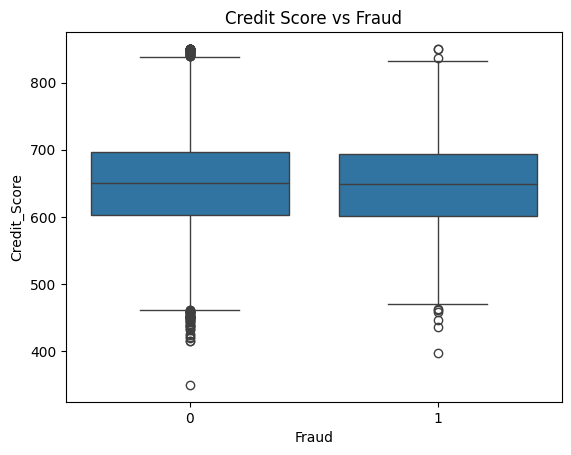

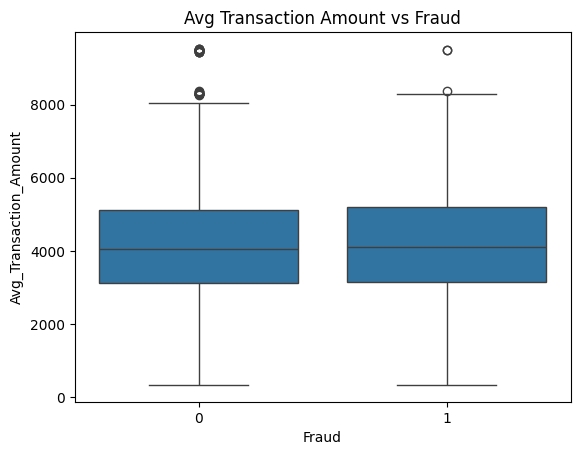

In [ ]:
from scipy.stats import pointbiserialr

# 1. Region Risk Score vs Fraud
r_region, p_region = pointbiserialr(df['Fraud'], df['Region_Risk_Score'])

# 2. Credit Score vs Fraud
r_credit, p_credit = pointbiserialr(df['Fraud'], df['Credit_Score'])

# 3. Avg Transaction Amount vs Fraud
r_txn, p_txn = pointbiserialr(df['Fraud'], df['Avg_Transaction_Amount'])

print("Region Risk Score correlation:", r_region, "p-value:", p_region)
print("Credit Score correlation:", r_credit, "p-value:", p_credit)
print("Avg Transaction Amount correlation:", r_txn, "p-value:", p_txn)



sns.boxplot(x='Fraud', y='Region_Risk_Score', data=df)
plt.title("Region Risk Score vs Fraud")
plt.show()


sns.boxplot(x='Fraud', y='Credit_Score', data=df)
plt.title("Credit Score vs Fraud")
plt.show()


sns.boxplot(x='Fraud', y='Avg_Transaction_Amount', data=df)
plt.title("Avg Transaction Amount vs Fraud")
plt.show()




# ANSWER 3
Region Risk Score's correlation = 0.0070, p-value ≈ 0.48

Credit Score's correlation = -0.0080, p-value ≈ 0.42

Average Transaction Amount's correlation = 0.0078, p-value ≈ 0.43

## **Interpretation**

Very weak correlation (close to 0)

All three values are near 0, meaning there’s almost no linear relationship between these features and fraud.

Not statistically significant (p > 0.05)

The high p-values mean the correlation is not significant — we can’t say these factors have a meaningful effect on fraud in this dataset.

## **Therefore**

Region Risk Score: Fraud doesn’t really depend on whether a region is labeled “high risk” or not.

Credit Score: Having a low credit score does not strongly predict fraud in this dataset.

Avg Transaction Amount: Transaction size also doesn’t determine fraud likelihood.

## **Final Answer:**

Region Risk Score, Credit Score, and Average Transaction Amount all show near-zero correlations with Fraud (r ≈ 0.007 to -0.008), with high p-values (> 0.4).

This indicates that in this dataset, none of these features are strongly related to fraud.

In other words, fraud seems to be influenced more by categorical factors (like Channel, Location, Account Type, etc.) than by these numerical variables.

# QUESTION 4
Based on the below persons, who, according to you, is most likely to commit fraud?
1. Age - 40, Location - Metro, Account Type - Current, Transaction Amount - ₹25,000, Time of Transaction - 02:30 AM,
Transaction Channel - Online, Device Used - Mobile App, Average Monthly Txns - 40, Average Transaction Amt -
18,000, Past Fraud Flag - Yes (1), Credit Score - 690, Digital Literacy - Low

2. Age: 38, Location: Semi-Urban, Account Type: Savings, Transaction Amount: ₹7,500, Time of Transaction: 3:00 PM,
Transaction Channel: ATM, Device Used: Card, Average Monthly Transactions: 18, Average Transaction Amount: ₹6,000,
Past Fraud Flag: 1, Credit Score: 720, Digital Literacy: Medium

3. Age: 44, Location: Rural, Account Type: Savings, Transaction Amount: ₹1,200, Time of Transaction: 11:00 AM,
Transaction Channel: Branch, Device Used: None (in-person), Average Monthly Transactions: 6, Average Transaction
Amount: ₹1,000, Past Fraud Flag: 1, Credit Score: 750, Digital Literacy: High

In [ ]:
# Sample data (the 3 persons)
data = [
    {
        "Person": "Person 1",
        "Age": 40, "Location": "Metro", "Account_Type": "Current",
        "Txn_Amount": 25000, "Txn_Time": "02:30", "Channel": "Online",
        "Device": "Mobile App", "Avg_Txn_Amt": 18000, "Past_Fraud": 1,
        "Credit_Score": 690, "Digital_Literacy": "Low"
    },
    {
        "Person": "Person 2",
        "Age": 38, "Location": "Semi-Urban", "Account_Type": "Savings",
        "Txn_Amount": 7500, "Txn_Time": "15:00", "Channel": "ATM",
        "Device": "Card", "Avg_Txn_Amt": 6000, "Past_Fraud": 1,
        "Credit_Score": 720, "Digital_Literacy": "Medium"
    },
    {
        "Person": "Person 3",
        "Age": 44, "Location": "Rural", "Account_Type": "Savings",
        "Txn_Amount": 1200, "Txn_Time": "11:00", "Channel": "Branch",
        "Device": "None", "Avg_Txn_Amt": 1000, "Past_Fraud": 1,
        "Credit_Score": 750, "Digital_Literacy": "High"
    }
]

df = pd.DataFrame(data)

# Function to calculate fraud risk score
def fraud_score(row):
    score = 0

    # Rule 1: Past fraud history
    score += 3 * row["Past_Fraud"]

    # Rule 2: Transaction amount much higher than average
    if row["Txn_Amount"] > 1.5 * row["Avg_Txn_Amt"]:
        score += 2

    # Rule 3: Odd transaction time (e.g., midnight to 5 AM)
    hour = int(row["Txn_Time"].split(":")[0])
    if hour < 5:
        score += 2

    # Rule 4: Channel risk
    if row["Channel"] == "Online":
        score += 2
    elif row["Channel"] == "ATM":
        score += 1

    # Rule 5: Digital literacy
    if row["Digital_Literacy"] == "Low":
        score += 2
    elif row["Digital_Literacy"] == "Medium":
        score += 1

    # Rule 6: Credit score
    if row["Credit_Score"] < 700:
        score += 2
    elif row["Credit_Score"] < 740:
        score += 1

    return score

# Apply scoring
df["Fraud_Risk_Score"] = df.apply(fraud_score, axis=1)

# finding who is most likely to commit fraud
most_likely = df.loc[df["Fraud_Risk_Score"].idxmax()]

print(df[["Person", "Fraud_Risk_Score"]])
print("Most likely to commit fraud:", most_likely["Person"])


     Person  Fraud_Risk_Score
0  Person 1                11
1  Person 2                 6
2  Person 3                 3

Most likely to commit fraud: Person 1


# ANSWER 4
Based on the fraud scoring function, Person 1 has the highest fraud risk score. The key reasons are:

1. Past fraud history

2. High/odd transaction behaviour

3. Riskier transaction channel (Online/ATM)

4. Low digital literacy / lower credit score

Thus, combining both numerical and categorical factors, Person 1 is most likely to commit fraud.